In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, ttest_ind, chi2_contingency, f_oneway , pearsonr ,linregress
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error

In [3]:
dt = pd.read_csv('LoansData.csv')

In [4]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Amount.Requested                2499 non-null   float64
 1   Amount.Funded.By.Investors      2499 non-null   float64
 2   Interest.Rate                   2498 non-null   object 
 3   Loan.Length                     2500 non-null   object 
 4   Loan.Purpose                    2500 non-null   object 
 5   Debt.To.Income.Ratio            2499 non-null   object 
 6   State                           2500 non-null   object 
 7   Home.Ownership                  2499 non-null   object 
 8   Monthly.Income                  2499 non-null   float64
 9   FICO.Range                      2498 non-null   object 
 10  Open.CREDIT.Lines               2497 non-null   float64
 11  Revolving.CREDIT.Balance        2497 non-null   float64
 12  Inquiries.in.the.Last.6.Months  24

In [5]:
dt.dropna(subset=['Amount.Requested' , 'Interest.Rate'] , inplace=True)

In [6]:
dt

,Amount.Requested,Amount.Funded.By.Investors,Interest.Rate,Loan.Length,Loan.Purpose,Debt.To.Income.Ratio,State,Home.Ownership,Monthly.Income,FICO.Range,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.in.the.Last.6.Months,Employment.Length
0,20000.0,20000.00,8.90%,36 months,debt_consolidation,14.90%,SC,MORTGAGE,6541.67,735-739,14.0,14272.0,2.0,< 1 year
1,19200.0,19200.00,12.12%,36 months,debt_consolidation,28.36%,TX,MORTGAGE,4583.33,715-719,12.0,11140.0,1.0,2 years
2,35000.0,35000.00,21.98%,60 months,debt_consolidation,23.81%,CA,MORTGAGE,11500.00,690-694,14.0,21977.0,1.0,2 years
3,10000.0,9975.00,9.99%,36 months,debt_consolidation,14.30%,KS,MORTGAGE,3833.33,695-699,10.0,9346.0,0.0,5 years
4,12000.0,12000.00,11.71%,36 months,credit_card,18.78%,NJ,RENT,3195.00,695-699,11.0,14469.0,0.0,9 years
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,30000.0,29950.00,16.77%,60 months,debt_consolidation,19.23%,NY,MORTGAGE,9250.00,705-709,15.0,45880.0,1.0,8 years
2496,16000.0,16000.00,14.09%,60 months,home_improvement,21.54%,MD,OWN,8903.25,740-744,18.0,18898.0,1.0,10+ years
2497,10000.0,10000.00,13.99%,36 months,debt_consolidation,4.89%,PA,MORTGAGE,2166.67,680-684,4.0,4544.0,0.0,10+ years
2498,6000.0,6000.00,12.42%,36 months,major_purchase,16.66%,NJ,RENT,3500.00,675-679,8.0,7753.0,0.0,5 years


In [7]:
amount_Requested = dt['Amount.Requested']

In [8]:
dt['Interest.Rate'] = dt['Interest.Rate'].str.replace('%' , '').astype(float)

In [9]:
interest_rate = dt['Interest.Rate']

In [10]:
corr , p_value = pearsonr(amount_Requested , interest_rate)

In [11]:
print(corr)
print(p_value)

0.3324537662008248
1.5803794085882206e-65


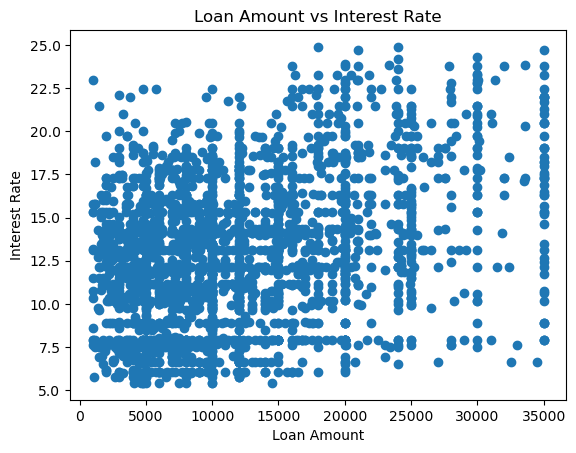

In [12]:
plt.figure()
plt.scatter(dt['Amount.Requested'], dt['Interest.Rate'])
plt.xlabel("Loan Amount")
plt.ylabel("Interest Rate")
plt.title("Loan Amount vs Interest Rate")
plt.show()


In [20]:
amount_Requested = pd.to_numeric(amount_Requested, errors='coerce')
interest_rate = pd.to_numeric(interest_rate, errors='coerce')


mask = (~amount_Requested.isna()) & (~interest_rate.isna())
x = amount_Requested[mask]
y = interest_rate[mask]

slope , intercept, r_value, p_value, std_err = linregress(x, y)

print("Slope:", slope)
print("Intercept:", intercept)
print("R:", r_value)
print("R²:", r_value**2)
print("p-value:", p_value)


Slope: 0.00017794320753239626
Intercept: 10.85810539855856
R: 0.3324537662008249
R²: 0.11052550666111274
p-value: 1.5803794085876933e-65


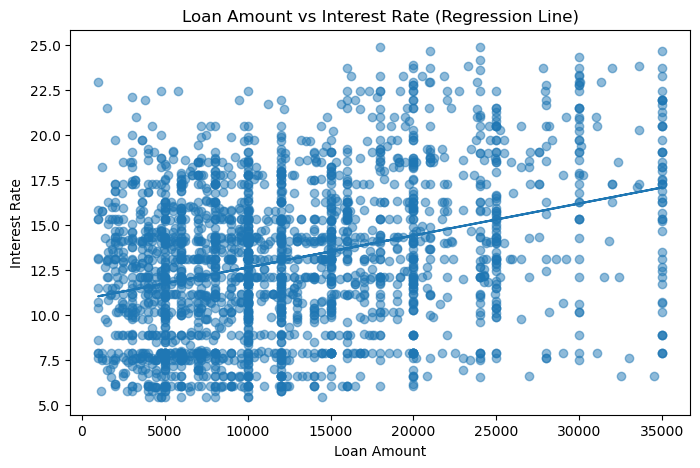

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.5)
y_pred = slope * x + intercept
plt.plot(x, y_pred)
plt.xlabel("Loan Amount")
plt.ylabel("Interest Rate")
plt.title("Loan Amount vs Interest Rate (Regression Line)")

plt.show()


In [22]:
dt['Loan.Length'] = dt['Loan.Length'].str.replace('months' , '').astype(int)

In [23]:
intrt_36 = dt[dt['Loan.Length'] == 36]['Interest.Rate']
intrt_36.mean()

np.float64(12.126179487179487)

In [24]:
intrt_60 = dt[dt['Loan.Length'] == 60]['Interest.Rate']
print(intrt_60.mean())
print(intrt_36.mean())

16.407463503649634
12.126179487179487


In [25]:
loan_lenght = dt['Loan.Length']

In [26]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(intrt_36, intrt_60, equal_var=False)

t_stat, p_value


(np.float64(-21.952945651707445), np.float64(3.9306165080480272e-84))

In [27]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis: Interest rates are significantly different")
else:
    print("Fail to Reject Null Hypothesis")


Reject Null Hypothesis: Interest rates are significantly different


In [28]:
dt['Loan.Purpose'].unique()

array(['debt_consolidation', 'credit_card', 'other', 'moving', 'car',
       'vacation', 'home_improvement', 'house', 'major_purchase',
       'educational', 'medical', 'wedding', 'small_business',
       'renewable_energy'], dtype=object)

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# sample data
data = {
    'age': [22, 35, 26, 40, 30],
    'salary': [20000, 50000, 25000, 60000, 40000],
    'churn': [1, 0, 1, 0, 0]
}

df = pd.DataFrame(data)

X = df[['age', 'salary']]
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


In [30]:
z_score = dt['Monthly.Income']

In [31]:
mean_z_score =  dt['Monthly.Income'].mean()

mean_z_score

In [32]:
mean_z_score

np.float64(5687.614217060473)

In [33]:
st = np.std(dt['Monthly.Income'])

In [34]:
st

3963.5933513672267

In [74]:
mean_z_score =  dt['Monthly.Income'].mean()
st = np.std(dt['Monthly.Income'])
z_scores = [(x - mean_z_score) / st for x in dt['Monthly.Income']]
print(z_scores)


[np.float64(0.2154751275493295), np.float64(-0.2786068395940653), np.float64(1.4664435192209027), np.float64(-0.4678290764668995), np.float64(-0.6288773837509478), np.float64(-0.20081379357090567), np.float64(-0.6990990173360356), np.float64(2.0627256779808945), np.float64(-0.6402307179633179), np.float64(-0.17348253367699354), np.float64(-0.5330047837353785), np.float64(-0.3627047705498277), np.float64(2.139234535756477), np.float64(0.8777529566042491), np.float64(1.4033694402632912), np.float64(-0.06835822775992177), np.float64(0.8357027296447888), np.float64(-0.3416809185516767), np.float64(-0.7453550238803895), np.float64(-0.48885292846505046), np.float64(0.2470121670281352), np.float64(0.1418878611110634), np.float64(-0.4005492179243945), np.float64(0.2890598710244372), np.float64(-0.29963069159221634), np.float64(-0.06835822775992177), np.float64(-0.6871149423340895), np.float64(-0.6990990173360356), np.float64(-0.3836453647637547), np.float64(-0.43629203698809377), np.float64(0.

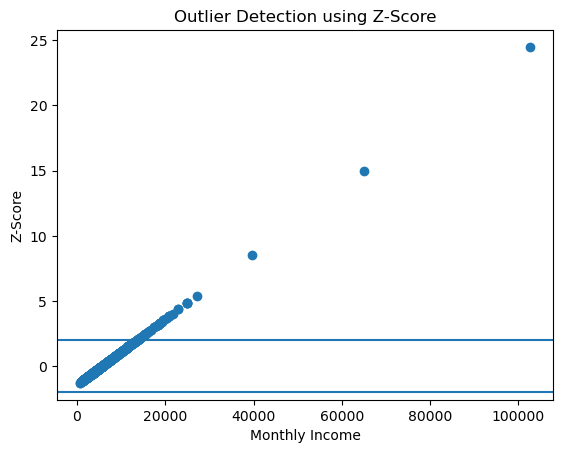

In [75]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(dt['Monthly.Income'], z_scores)
plt.axhline(2)
plt.axhline(-2)
plt.xlabel("Monthly Income")
plt.ylabel("Z-Score")
plt.title("Outlier Detection using Z-Score")
plt.show()


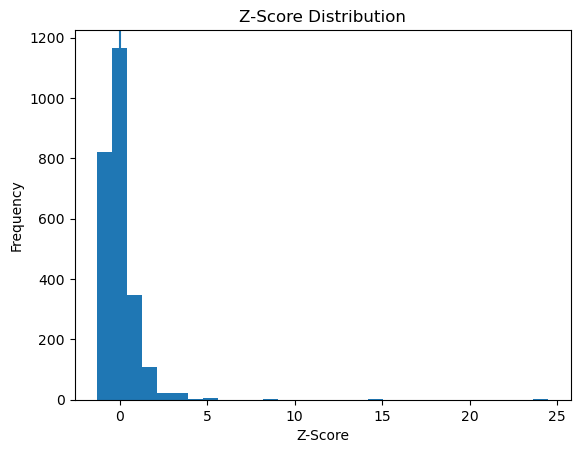

In [76]:
plt.figure()
plt.hist(z_scores, bins=30)
plt.axvline(0)
plt.xlabel("Z-Score")
plt.ylabel("Frequency")
plt.title("Z-Score Distribution")
plt.show()


In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Random seed taaki har baar same result aaye
np.random.seed(42)

# 1. Study Hours (Input Feature) - Average 5 ghante, thoda spread ke saath
study_hours = np.random.normal(5, 2, 1000) 

# 2. Exam Marks (Target) - Jitna padhoge utne marks, plus thoda random luck/error
exam_marks = (study_hours * 15) + np.random.normal(10, 5, 1000)

# DataFrame banana
df = pd.DataFrame({'Study_Hours': study_hours, 'Exam_Marks': exam_marks})
print(df.head(50))

    Study_Hours  Exam_Marks
0      5.993428  106.898202
1      4.723471   85.475239
2      6.295377  104.728808
3      8.046060  127.456212
4      4.531693   81.466515
5      4.531726   79.943318
6      8.158426  136.852351
7      6.534869  111.198901
8      4.061051   76.163532
9      6.085120   98.600625
10     4.073165   77.684440
11     4.068540   72.016105
12     5.483925  102.635173
13     1.173440   24.155654
14     1.550164   41.932284
15     3.875425   69.120928
16     2.974338   51.357976
17     5.628495   92.007991
18     3.183952   56.157541
19     2.175393   44.751719
20     7.931298  131.583641
21     4.548447   75.358211
22     5.135056   86.904073
23     2.150504   52.968906
24     3.911235   77.306234
25     5.221845   90.509296
26     2.698013   50.660210
27     5.751396   96.871097
28     3.798723   70.048429
29     4.416613   71.135225
30     3.796587   65.661919
31     8.704556  132.225425
32     4.973006   86.591199
33     2.884578   56.504652
34     6.645090  107

Correlation between Study and Marks: 0.99


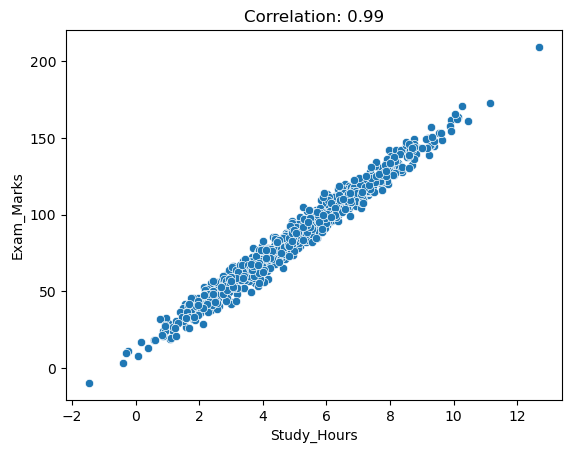

In [39]:
correlation = df['Study_Hours'].corr(df['Exam_Marks'])
print(f"Correlation between Study and Marks: {correlation:.2f}")

# Visualize karne ke liye Scatter Plot
sns.scatterplot(data=df, x='Study_Hours', y='Exam_Marks')
plt.title(f"Correlation: {correlation:.2f}")
plt.show()

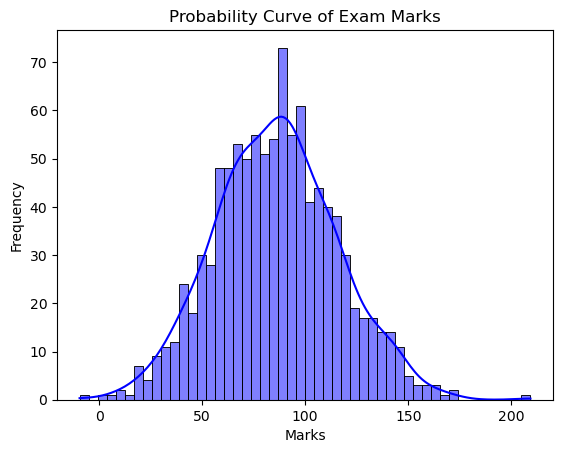

In [42]:
# Marks ki distribution (Probability Curve)
sns.histplot(df['Exam_Marks'], bins = 50 ,kde=True ,color='blue')
plt.title("Probability Curve of Exam Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()

In [43]:
# 80 se zyada marks lane waale students count karo
count_above_80 = len(df[df['Exam_Marks'] > 80])

# Probability = Favorable / Total
probability_80 = count_above_80 / len(df)

print(f"Probability of scoring more than 80: {probability_80 * 100}%")

Probability of scoring more than 80: 57.49999999999999%


In [44]:
dt[['Amount.Requested','Amount.Funded.By.Investors','Interest.Rate','Loan.Length','Revolving.CREDIT.Balance','Monthly.Income']].corr()

,Amount.Requested,Amount.Funded.By.Investors,Interest.Rate,Loan.Length,Revolving.CREDIT.Balance,Monthly.Income
Amount.Requested,1.000000,0.969842,0.332454,0.412719,0.295073,0.389508
Amount.Funded.By.Investors,0.969842,1.000000,0.337454,0.406644,0.263407,0.372263
Interest.Rate,0.332454,0.337454,1.000000,0.424220,0.061746,0.011968
Loan.Length,0.412719,0.406644,0.424220,1.000000,0.056546,0.074150
Revolving.CREDIT.Balance,0.295073,0.263407,0.061746,0.056546,1.000000,0.359737
Monthly.Income,0.389508,0.372263,0.011968,0.074150,0.359737,1.000000


In [45]:
dt

,Amount.Requested,Amount.Funded.By.Investors,Interest.Rate,Loan.Length,Loan.Purpose,Debt.To.Income.Ratio,State,Home.Ownership,Monthly.Income,FICO.Range,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.in.the.Last.6.Months,Employment.Length
0,20000.0,20000.00,8.90,36,debt_consolidation,14.90%,SC,MORTGAGE,6541.67,735-739,14.0,14272.0,2.0,< 1 year
1,19200.0,19200.00,12.12,36,debt_consolidation,28.36%,TX,MORTGAGE,4583.33,715-719,12.0,11140.0,1.0,2 years
2,35000.0,35000.00,21.98,60,debt_consolidation,23.81%,CA,MORTGAGE,11500.00,690-694,14.0,21977.0,1.0,2 years
3,10000.0,9975.00,9.99,36,debt_consolidation,14.30%,KS,MORTGAGE,3833.33,695-699,10.0,9346.0,0.0,5 years
4,12000.0,12000.00,11.71,36,credit_card,18.78%,NJ,RENT,3195.00,695-699,11.0,14469.0,0.0,9 years
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,30000.0,29950.00,16.77,60,debt_consolidation,19.23%,NY,MORTGAGE,9250.00,705-709,15.0,45880.0,1.0,8 years
2496,16000.0,16000.00,14.09,60,home_improvement,21.54%,MD,OWN,8903.25,740-744,18.0,18898.0,1.0,10+ years
2497,10000.0,10000.00,13.99,36,debt_consolidation,4.89%,PA,MORTGAGE,2166.67,680-684,4.0,4544.0,0.0,10+ years
2498,6000.0,6000.00,12.42,36,major_purchase,16.66%,NJ,RENT,3500.00,675-679,8.0,7753.0,0.0,5 years


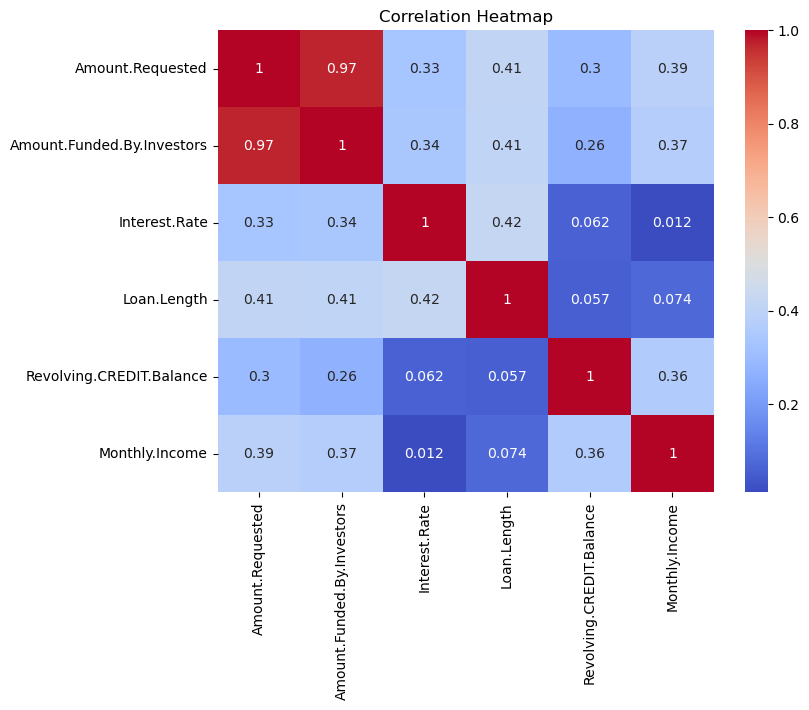

In [46]:
corrr= dt[['Amount.Requested','Amount.Funded.By.Investors','Interest.Rate','Loan.Length','Revolving.CREDIT.Balance','Monthly.Income']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corrr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [47]:
dt.groupby('Loan.Length')['Interest.Rate'].mean()



Loan.Length
36    12.126179
60    16.407464
Name: Interest.Rate, dtype: float64

In [48]:
dt['income_group'] = pd.cut(dt['Monthly.Income'], bins=5)
dt.groupby('income_group')['Interest.Rate'].mean()


C:\Users\piyus_baj2nxw\AppData\Local\Temp\ipykernel_12904\755637801.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dt.groupby('income_group')['Interest.Rate'].mean()


income_group
(486.338, 21020.8]     13.078693
(21020.8, 41453.1]     11.305556
(41453.1, 61885.4]           NaN
(61885.4, 82317.7]      6.910000
(82317.7, 102750.0]     7.620000
Name: Interest.Rate, dtype: float64

In [49]:
df1 = pd.read_csv('Price_Quotes.csv')

array([[<Axes: title={'center': 'Order_Number'}>,
        <Axes: title={'center': 'Barry_Price'}>],
       [<Axes: title={'center': 'Mary_Price'}>, <Axes: >]], dtype=object)

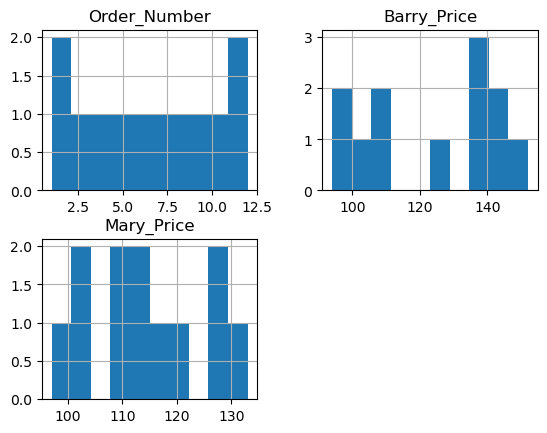

In [50]:
df1.hist()

In [51]:
barry_mean = df1['Barry_Price'].mean()
marry_mean = df1['Mary_Price'].mean()
print(barry_mean)
print(marry_mean)

124.33333333333333
114.75


In [52]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(df1['Barry_Price'], df1['Mary_Price'])

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: 2.5213765108923494
p-value: 0.02840588045242053


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, ttest_ind, chi2_contingency, f_oneway
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error

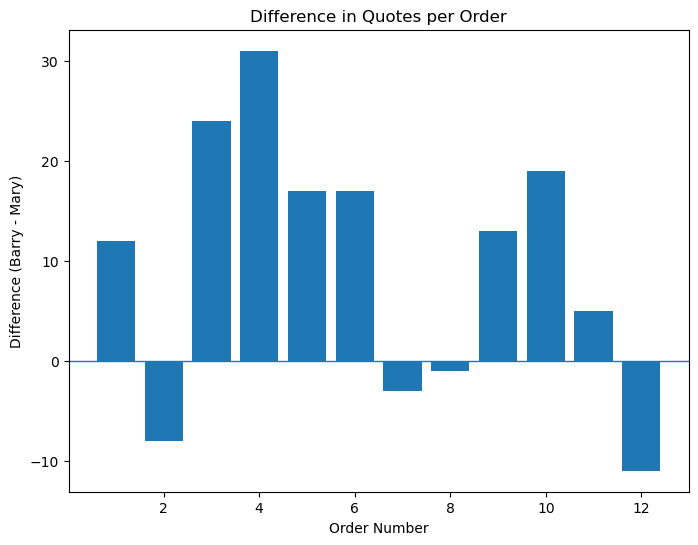

In [54]:
import matplotlib.pyplot as plt

df1['diff'] = df1['Barry_Price'] - df1['Mary_Price']

plt.figure(figsize=(8,6))
plt.bar(df1['Order_Number'], df1['diff'])
plt.axhline(0, linewidth=1)

plt.xlabel("Order Number")
plt.ylabel("Difference (Barry - Mary)")
plt.title("Difference in Quotes per Order")
plt.show()


In [55]:
treantment = pd.read_csv('Treatment_Facility.csv')



In [56]:
prior4 = treantment[treantment['Reengineer'] == 'Prior']['VAR4'].mean()
prior5 = treantment[treantment['Reengineer'] == 'Prior']['VAR5'].mean()
post4 = treantment[treantment['Reengineer'] == 'Post']['VAR4'].mean()
post5 = treantment[treantment['Reengineer'] == 'Post']['VAR5'].mean()
print(prior4)
print(prior5)
print(post4)
print(post5)


20.54033531733077
53.887906321846145
9.232041695285714
23.34971927988571


In [57]:
print(prior4)
print(prior5)
print(post4)
print(post5)

20.54033531733077
53.887906321846145
9.232041695285714
23.34971927988571


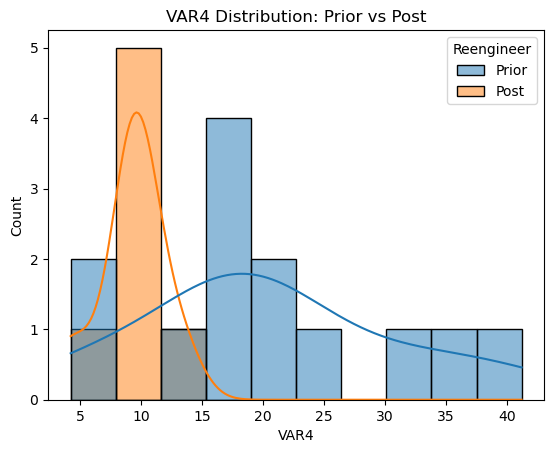

In [58]:
sns.histplot(data=treantment, x='VAR4', hue='Reengineer', bins=10, kde=True)
plt.title("VAR4 Distribution: Prior vs Post")
plt.show()


In [59]:
assessment = pd.read_csv('Priority_Assessment.csv')

In [60]:
assessment

,Days,Priority
0,3.3,High
1,7.9,Medium
2,0.3,High
3,0.7,Medium
4,8.6,Medium
...,...,...
637,2.5,Low
638,0.3,High
639,0.3,Medium
640,1.3,Medium


In [61]:
 high = assessment[assessment["Priority"]=='High']["Days"]
 medium = assessment[assessment["Priority"]=='Medium']["Days"]
 low = assessment[assessment["Priority"]=='Low']["Days"]

f_stat , p_value = f_oneway(high,medium,low)

print(f_stat)
print(p_value)

1.812311010076072
0.16411459461716182


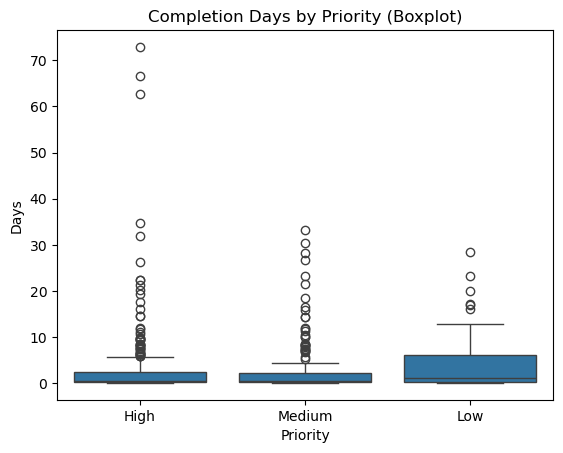

In [62]:
sns.boxplot(x="Priority", y="Days", data=assessment)
plt.title("Completion Days by Priority (Boxplot)")
plt.show()

In [63]:
assessment.describe()

,Days
count,642.000000
mean,2.946262
std,6.687063
min,0.100000
25%,0.200000
50%,0.600000
75%,2.500000
max,72.900000


In [64]:
assessment["Priority"].unique()

array(['High', 'Medium', 'Low'], dtype=object)

In [65]:
clean_df = pd.DataFrame()

for i in assessment['Priority'].unique():
    temp = assessment[assessment['Priority']==i]

    q1 = temp['Days'].quantile(0.25)
    q3 = temp['Days'].quantile(0.75)
    iqr = q3-q1

    low = q1-1.5*iqr
    higher = q3+1.5*iqr

    temp = temp[(temp['Days']>= low) & (temp['Days']<=higher)]
    clean_df = pd.concat([clean_df,temp])


In [66]:
clean_df

,Days,Priority
0,3.3,High
2,0.3,High
5,0.3,High
6,0.3,High
7,0.3,High
...,...,...
609,0.5,Low
613,7.9,Low
620,0.3,Low
622,0.1,Low


In [67]:
clean_df.groupby('Priority')['Days'].mean()

Priority
High      0.975445
Low       2.642623
Medium    0.962385
Name: Days, dtype: float64

In [68]:
high = clean_df[clean_df["Priority"]=='High']["Days"]
medium = clean_df[clean_df["Priority"]=='Medium']["Days"]
low = clean_df[clean_df["Priority"]=='Low']["Days"]

f_stat , p_value = f_oneway(high,medium,low)

print(f_stat)
print(p_value)

29.97904532038677
4.309922665472771e-13


In [69]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=clean_df["Days"], groups=clean_df["Priority"], alpha=0.05)
print(tukey)


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  High    Low   1.6672    0.0  1.1384 2.1959   True
  High Medium  -0.0131 0.9955 -0.3509 0.3248  False
   Low Medium  -1.6802    0.0 -2.2224 -1.138   True
---------------------------------------------------
